## Example: 2D simulation of Taylor Green Vortex using Lattice Boltzmann Method


The example solves the Naiver Stokes Equation using Lattice Boltzmann Method. Here we setup the problem using an analytical solution of N-S equation: Taylor Green Vortex. Its velocity field and pressure field can be written as


$$u= -u_{\max} \cos \frac{2\pi x}{L} \sin \frac{2\pi y}{L} e^{-\nu t} $$ 

$$ v=u_{\max}\sin \frac{2\pi x}{L} \cos \frac{2\pi y}{L} e^{-\nu t} $$

$$p= -\frac {1}{4}  \rho_0 u_{\max}^2 ( \cos \frac{2\pi x}{L} + \cos \frac{2\pi y}{L} ) e^{-2\nu t} $$

Here, the Boltzmann equation is written as

$$\frac{\partial f}{\partial t}+ \xi_\alpha \frac{\partial f}{\partial x_\alpha} +\frac{f_\alpha}{\rho}\frac{\partial f}{\partial \xi_\alpha}=\Omega(f),$$

where the probability density function $f(\mathbf{x},\mathbf{\xi}, t)$, which is defined as a function of location $\mathbf{x}$, microscopic particle velocity $\mathbf{\xi}$, and time $t$. $f_\alpha$ is external forcing, and $\Omega(f)$ is the collision term.

The problem is solved in 2D using D2Q9 discretization, and the collision term is solved using BGK operator.


## Running the code

The simulation can be ran as `./mained.gnu.ex inputs`. 

The following inputs parameters could be tweaked:

```
scale = 2              # scale of the problem
max_grid_size = 64                # max grid size used for domain decomposition
Nx = 32    # size of the domain in both directions are Nx*scale
NSTEP=200  # number of time steps is NSTEP*scale*scale
plot_int=50 # interval of saving data, if not save, then set as -1
```


## Visualizating the results

Below we give some python code to visualizate the solution using yt:

In [12]:
import yt
from yt.frontends import boxlib
from yt.frontends.boxlib.data_structures import AMReXDataset

yt : [INFO     ] 2025-03-09 18:45:27,541 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-03-09 18:45:27,542 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-03-09 18:45:27,543 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-09 18:45:27,544 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2025-03-09 18:45:27,750 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 18:45:27,751 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 18:45:27,755 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 18:45:27,756 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 18:45:27,760 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'f_old_0'), ('boxlib', 'f_old_1'), ('boxlib', 'f_old_2'), ('boxlib', 'f_old_3'), ('boxlib', 'f_old_4'), ('boxlib', 'f_old_5'), ('boxlib', 'f_old_6'), ('boxlib', 'f_old_7'), ('boxlib', 'f_old_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy')]



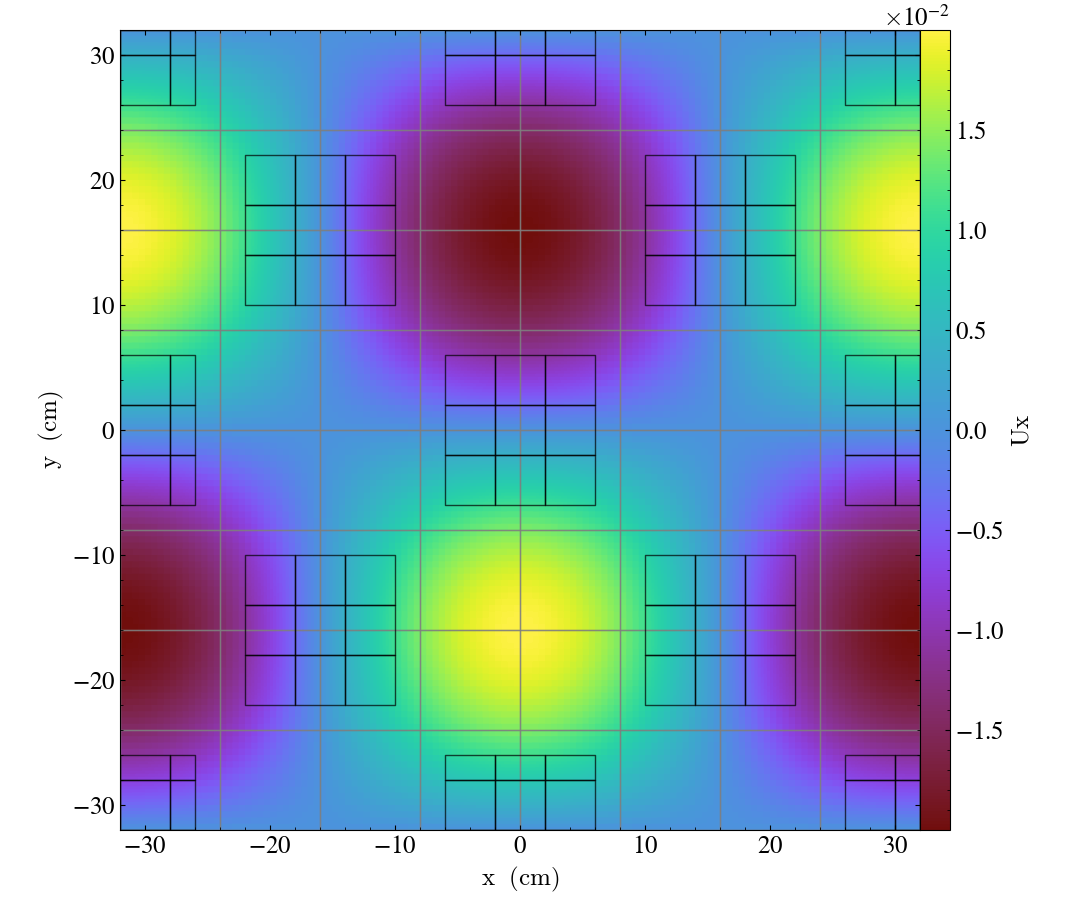

In [13]:
ds = AMReXDataset("plt00000")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux")

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()

yt : [INFO     ] 2025-03-09 19:09:57,933 Parameters: current_time              = 100.0
yt : [INFO     ] 2025-03-09 19:09:57,934 Parameters: domain_dimensions         = [64 64  1]
yt : [INFO     ] 2025-03-09 19:09:57,936 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-03-09 19:09:57,937 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2025-03-09 19:09:58,125 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 19:09:58,126 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 19:09:58,129 xlim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 19:09:58,129 ylim = 0.000000 64.000000
yt : [INFO     ] 2025-03-09 19:09:58,131 Making a fixed resolution buffer of (('boxlib', 'ux')) 800 by 800


Available fields: [('boxlib', 'f_old_0'), ('boxlib', 'f_old_1'), ('boxlib', 'f_old_2'), ('boxlib', 'f_old_3'), ('boxlib', 'f_old_4'), ('boxlib', 'f_old_5'), ('boxlib', 'f_old_6'), ('boxlib', 'f_old_7'), ('boxlib', 'f_old_8'), ('boxlib', 'rho'), ('boxlib', 'ux'), ('boxlib', 'uy')]



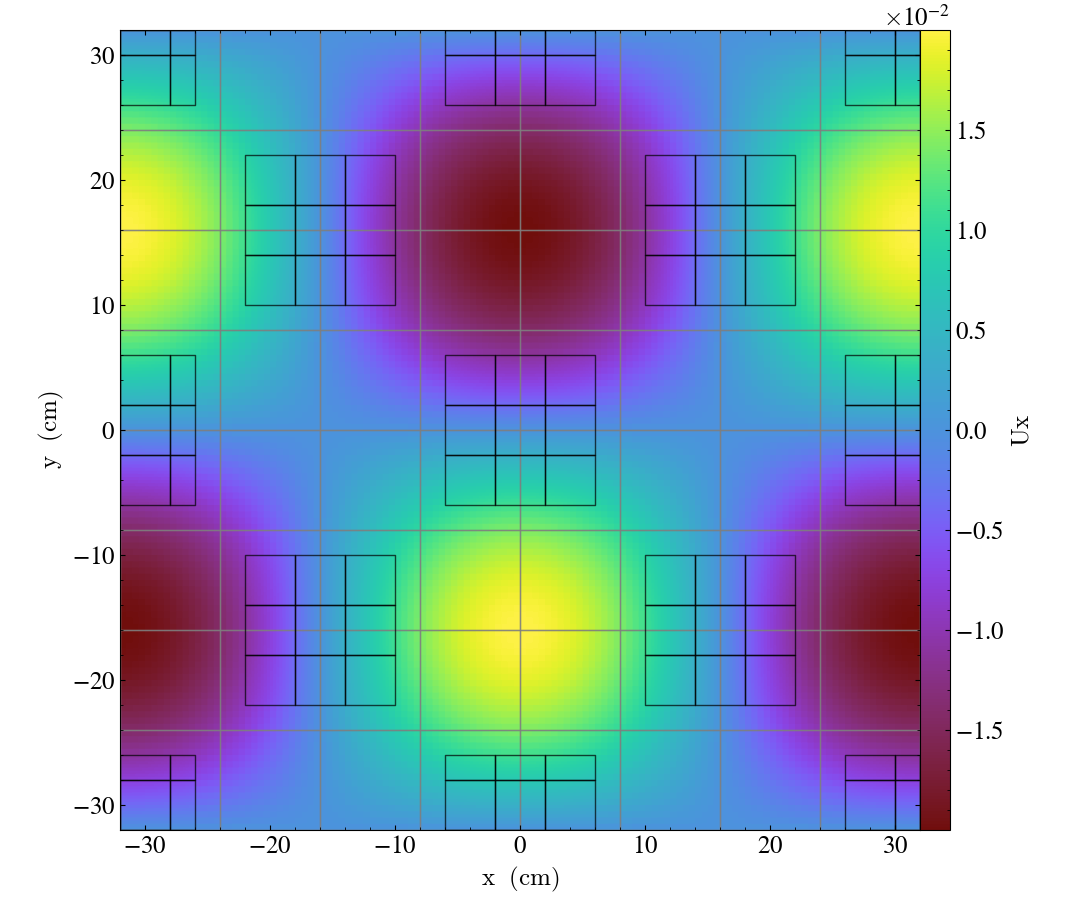

In [ ]:
ds = AMReXDataset("plt00150")
print("Available fields:", ds.field_list)
field = ("boxlib", "ux")

slc = yt.SlicePlot(ds, "z", field)
slc.set_log(field, False)  # Set to True if you want a log scale
slc.annotate_grids()  # Show AMR grid structure
slc.show()
# # Projection plot (integrates field along z-axis)
# proj = yt.ProjectionPlot(ds, "z", field)
# proj.set_log(field, False)
# proj.annotate_grids()
# proj.show()